# Text as Data: Tokens, Normalization, Zipf — companion notebook

Chapter 2 of *Applied Natural Language Processing — From Tokens to Agents*.
Read the chapter first: **[Text as Data](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html)**.

The chapter builds the bridge from a string of characters to numbers a model can use, and
it has two spans: *decide what the units are* (tokenization) and *decide what number each
unit contributes* (weighting). The chapter's status note says every number and code output
on its page came from running code. This notebook runs that code, in the chapter's order:

1. **From characters to tokens**: whitespace splitting, the Turkish lowercasing trap, a
   byte-pair encoder built from scratch, and what Turkish costs in OpenAI's tokenizers.
2. **Zipf's law and Heaps' law** on 20 Newsgroups, including the `'ax` artefact, and a
   demonstration of why the Zipf exponent should not be fitted with a regression.
3. **How a word becomes a vector**: the six steps from four maintenance logs to TF-IDF
   vectors, cosine similarity, and $\lVert a-b \rVert^2 = 2 - 2\cos(a,b)$.
4. **What bag-of-words cannot do**: word order, n-grams, negation.
5. **Does any of this still matter?** The chapter's logistic regression experiment, the
   sparse matrix it runs on, and BM25.
6. **Numbers from the intuition checks and interview questions.**

**How to read the numbers.** Everything printed below is what *this run* produced. Where
the chapter prints the same output, the cell prints the book's value beside it, or compares
the whole printed block line by line, and says whether the two match. Where the chapter
prints an output but not the code that made it, the code here is our reading of the prose,
and the cell says so. Timings depend on your machine.

**Interactive figures.** The chapter's explorers (the BPE merge replay, the Zipf plot, the
IDF curve, the document-term matrix) are Observable widgets and cannot run in a notebook.
Where they teach something the printed numbers do not, there is a small static plot instead.

**Runtime.** About a minute on a laptop CPU, most of it the first download: the 20
Newsgroups archive (about 14 MB) and two tokenizer vocabularies (about 5 MB together). No
cell is heavy, so `ANLP_SKIP_HEAVY=1` changes nothing here.

## 0. Setup

The first cell records the interpreter and package versions. The chapter's status note
names `scikit-learn` 1.9 and `tiktoken` 0.13; the book's own measurements ran on Python
3.14.5 ([Appendix A](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/appendices/a-setup.html)). If your numbers differ from the ones saved here, compare this
cell first.

Downloads are cached under `data/cache/` at the root of the notebooks repository, which git
ignores, so a second run reads them from disk. Run outside the repository, the notebook
caches them under `data/cache/` next to itself instead.

In [1]:
import io
import math
import os
import platform
import re
import sys
import time
import unicodedata
from collections import Counter
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

here = Path.cwd()
repo_root = next((p for p in [here, *here.parents] if (p / "scripts" / "check-structure.py").exists()), here)
CACHE = repo_root / "data" / "cache"
os.environ.setdefault("TIKTOKEN_CACHE_DIR", str(CACHE / "tiktoken"))  # tokenizer vocabularies
DATA_HOME = str(CACHE / "scikit_learn_data")                           # the 20 Newsgroups archive

print(f"Python        {platform.python_version()}  ({platform.system()} {platform.machine()})")
for pkg in ["numpy", "scipy", "scikit-learn", "tiktoken", "matplotlib"]:
    print(f"{pkg:<13} {version(pkg)}")

Python        3.12.13  (Darwin arm64)
numpy         2.5.2
scipy         1.18.1
scikit-learn  1.9.0
tiktoken      0.13.0
matplotlib    3.11.2


Two helpers do the comparing. `vs_book` puts one number beside the book's, formatted at the
book's printed precision. `record()` starts keeping a copy of everything a cell prints, and
`compare_with_book(...)` checks that copy against the output block the chapter prints. It
says *line for line* when every character matches, and *only the spacing differs* when the
values match but the columns are padded differently (the book sometimes prints NumPy
arrays with the padding removed).

In [2]:
def vs_book(label, ours, book, fmt="{:,}"):
    """Print this run's value beside the book's, compared at the book's printed precision."""
    ours_s, book_s = fmt.format(ours), fmt.format(book)
    verdict = "same as the book" if ours_s == book_s else "DIFFERS from the book"
    print(f"{label:<38} this run {ours_s:>9}   book {book_s:>9}   {verdict}")


class _Tee(io.TextIOBase):
    """Writes to the notebook as usual and keeps a copy."""

    def __init__(self, stream):
        self.stream, self.copy = stream, io.StringIO()

    def write(self, s):
        self.copy.write(s)
        self.stream.write(s)
        return len(s)

    def flush(self):
        self.stream.flush()


def record():
    """Start keeping a copy of everything printed, to compare with the book's output."""
    if isinstance(sys.stdout, _Tee):
        sys.stdout = sys.stdout.stream
    sys.stdout = _Tee(sys.stdout)


def _squash(lines):
    """Collapse runs of spaces, and the padding NumPy puts inside brackets."""
    return [re.sub(r"\[ +| +\]", lambda m: m.group().strip(), " ".join(line.split())) for line in lines]


def compare_with_book(book_text):
    """Stop recording, and compare what was printed with the output block the book prints."""
    if not isinstance(sys.stdout, _Tee):
        raise RuntimeError("call record() before the code whose output you want to compare")
    ours_text = sys.stdout.copy.getvalue()
    sys.stdout = sys.stdout.stream
    ours = [line.rstrip() for line in ours_text.strip("\n").splitlines()]
    book = [line.rstrip() for line in book_text.strip("\n").splitlines()]
    print()
    if ours == book:
        print(f"-> same as the book, line for line ({len(book)} lines)")
    elif _squash(ours) == _squash(book):
        print(f"-> same values as the book ({len(book)} lines); only the spacing differs")
    else:
        print("-> DIFFERS from the book:")
        for k in range(max(len(ours), len(book))):
            o = ours[k] if k < len(ours) else "(no line)"
            b = book[k] if k < len(book) else "(no line)"
            if " ".join(o.split()) != " ".join(b.split()):
                print(f"   line {k + 1}\n     this run: {o}\n     book    : {b}")

## 1. From characters to tokens

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#sec-text-as-data-tokens). Before a model can count anything,
something has to decide what a *thing* is. The obvious first move is to split on
whitespace, and it fails immediately.

**What to look at:** `fail;` and `fail` would be different tokens, and so would `The` and
`the`.

In [3]:
record()
text = "The pump P-101 didn't fail; it's the seal (again!)."
print(text.split())
compare_with_book("""
['The', 'pump', 'P-101', "didn't", 'fail;', "it's", 'the', 'seal', '(again!).']
""")

['The', 'pump', 'P-101', "didn't", 'fail;', "it's", 'the', 'seal', '(again!).']



-> same as the book, line for line (1 lines)


### 1a. Lowercasing is a language-dependent operation

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#sec-text-as-data-normalization). Python's `str.lower()` applies
the Unicode *default* case mapping, not the Turkish tailoring. Turkish has two `i` letters
and two `I` letters, so the default mapping is wrong for it, silently.

The chapter's three lines give their results as comments. The cell also lists the code
points of the first two characters, so you can see the combining dot above (U+0307).

In [4]:
lowered = "İSTANBUL".lower()
print(f'"İSTANBUL".lower() = {lowered!r}   code points of its first two characters: '
      f'{[f"U+{ord(c):04X}" for c in lowered[:2]]}')
print()
vs_book('len("İSTANBUL".lower())', len(lowered), 9)
vs_book('"İSTANBUL".lower() == "istanbul"', lowered == "istanbul", False, "{}")
vs_book('"IĞDIR".lower()', "IĞDIR".lower(), "iğdir", "{}")
print('\nwhat a Turkish reader expects from "IĞDIR": "ığdır"')

"İSTANBUL".lower() = 'i̇stanbul'   code points of its first two characters: ['U+0069', 'U+0307']

len("İSTANBUL".lower())                this run         9   book         9   same as the book
"İSTANBUL".lower() == "istanbul"       this run     False   book     False   same as the book
"IĞDIR".lower()                        this run     iğdir   book     iğdir   same as the book

what a Turkish reader expects from "IĞDIR": "ığdır"


**Reading it.** Nothing errors. `İSTANBUL` becomes nine characters, `i` plus a combining dot,
so it lands in a different vocabulary column from the `istanbul` a user types, and `IĞDIR`
becomes `iğdir` where Turkish needs `ığdır`. [Chapter 4](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/04-bake-off.html) hits this bug on a real
corpus and [chapter 16](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/16-turkish-nlp.html#sec-turkish-nlp-normalization) gives the locale-aware fix.

The chapter's stop word callout in this section uses the corpus from section 2, so its
check is there, right after the corpus is loaded.

### 1b. Byte-pair encoding from scratch

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#sec-text-as-data-bpe). Start with characters, count every
adjacent pair, merge the most frequent pair into a new symbol, repeat. The code is the
chapter's, line for line.

**What to look at:** the first three merges build `est</w>`, the English superlative with
its word boundary, and nobody told the algorithm that English has suffixes.

In [5]:
record()
from collections import Counter

corpus = {"low": 5, "lower": 2, "newest": 6, "widest": 3}
words = {tuple(w) + ("</w>",): n for w, n in corpus.items()}

def pair_counts(words):
    pairs = Counter()
    for symbols, freq in words.items():
        for a, b in zip(symbols, symbols[1:]):
            pairs[(a, b)] += freq
    return pairs

def merge(words, pair):
    a, b = pair
    out = {}
    for symbols, freq in words.items():
        new, i = [], 0
        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == a and symbols[i + 1] == b:
                new.append(a + b)
                i += 2
            else:
                new.append(symbols[i])
                i += 1
        out[tuple(new)] = freq
    return out

merges = []
for step in range(1, 11):
    best, count = pair_counts(words).most_common(1)[0]
    merges.append(best)
    words = merge(words, best)
    print(f"merge {step:>2}: {best[0]!r} + {best[1]!r} -> "
          f"{best[0] + best[1]!r}  (seen {count} times)")
compare_with_book("""
merge  1: 'e' + 's' -> 'es'  (seen 9 times)
merge  2: 'es' + 't' -> 'est'  (seen 9 times)
merge  3: 'est' + '</w>' -> 'est</w>'  (seen 9 times)
merge  4: 'l' + 'o' -> 'lo'  (seen 7 times)
merge  5: 'lo' + 'w' -> 'low'  (seen 7 times)
merge  6: 'n' + 'e' -> 'ne'  (seen 6 times)
merge  7: 'ne' + 'w' -> 'new'  (seen 6 times)
merge  8: 'new' + 'est</w>' -> 'newest</w>'  (seen 6 times)
merge  9: 'low' + '</w>' -> 'low</w>'  (seen 5 times)
merge 10: 'w' + 'i' -> 'wi'  (seen 3 times)
""")

merge  1: 'e' + 's' -> 'es'  (seen 9 times)
merge  2: 'es' + 't' -> 'est'  (seen 9 times)
merge  3: 'est' + '</w>' -> 'est</w>'  (seen 9 times)
merge  4: 'l' + 'o' -> 'lo'  (seen 7 times)
merge  5: 'lo' + 'w' -> 'low'  (seen 7 times)
merge  6: 'n' + 'e' -> 'ne'  (seen 6 times)
merge  7: 'ne' + 'w' -> 'new'  (seen 6 times)
merge  8: 'new' + 'est</w>' -> 'newest</w>'  (seen 6 times)
merge  9: 'low' + '</w>' -> 'low</w>'  (seen 5 times)
merge 10: 'w' + 'i' -> 'wi'  (seen 3 times)



-> same as the book, line for line (10 lines)


To tokenize, replay the learned merges in the order they were learned. `lowest` never
appeared in training. This cell is also the notebook's stand-in for the chapter's BPE
explorer: add your own words to the list and re-run it.

In [6]:
record()
def apply_merges(word, merges):
    symbols = tuple(word) + ("</w>",)
    for pair in merges:
        symbols = tuple(merge({symbols: 1}, pair).keys())[0]
    return symbols

for w in ["lowest", "newer", "slow", "widest"]:
    print(f"{w:<8} -> {' '.join(apply_merges(w, merges))}")
compare_with_book("""
lowest   -> low est</w>
newer    -> new e r </w>
slow     -> s low</w>
widest   -> wi d est</w>
""")

lowest   -> low est</w>
newer    -> new e r </w>
slow     -> s low</w>
widest   -> wi d est</w>



-> same as the book, line for line (4 lines)


**The caveat.** The merge table was learned over *characters*, from an alphabet of only
the letters in `low`, `lower`, `newest` and `widest`. So an unseen **character** still
breaks it. The cell lists the symbols the toy tokenizer knows (its starting symbols plus
the ten merges) and checks each piece of `çay` against them.

In [7]:
pieces = apply_merges("çay", merges)
vs_book('apply_merges("çay", merges)', repr(pieces), "('ç', 'a', 'y', '</w>')", "{}")

known = {s for w in corpus for s in tuple(w) + ("</w>",)} | {a + b for a, b in merges}
print(f"\nsymbols the toy tokenizer knows ({len(known)}): {sorted(known)}")
for p in pieces:
    print(f"  {p!r:<7} {'known' if p in known else 'never seen in training'}")

apply_merges("çay", merges)            this run ('ç', 'a', 'y', '</w>')   book ('ç', 'a', 'y', '</w>')   same as the book

symbols the toy tokenizer knows (21): ['</w>', 'd', 'e', 'es', 'est', 'est</w>', 'i', 'l', 'lo', 'low', 'low</w>', 'n', 'ne', 'new', 'newest</w>', 'o', 'r', 's', 't', 'w', 'wi']
  'ç'     never seen in training
  'a'     never seen in training
  'y'     never seen in training
  '</w>'  known


**Reading it.** `ç`, `a` and `y` never occurred in the training words, so no merge can
touch them. The fourth piece is the end-of-word marker `</w>`, which the procedure appends
to every word. Real tokenizers close this hole by starting from the 256 possible **bytes**
of UTF-8 rather than from characters, so they can represent every string by construction.

### 1c. Who pays for Turkish

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#sec-text-as-data-turkish). Article 1 of the Universal Declaration
of Human Rights, in its official English and Turkish texts (published by the United
Nations), run through two of OpenAI's tokenizers. The code is the chapter's.

The first call downloads each encoding's vocabulary file from OpenAI's public blob storage
and caches it under `data/cache/tiktoken`. The chapter says every measurement in this
section was taken after Unicode NFC normalization, so the cell checks that both strings are
already in NFC.

In [8]:
record()
import tiktoken

en = ("All human beings are born free and equal in dignity and rights. "
      "They are endowed with reason and conscience and should act towards "
      "one another in a spirit of brotherhood.")
tr = ("Bütün insanlar hür, haysiyet ve haklar bakımından eşit doğarlar. "
      "Akıl ve vicdana sahiptirler ve birbirlerine karşı kardeşlik "
      "zihniyeti ile hareket etmelidirler.")

for name in ["cl100k_base", "o200k_base"]:
    enc = tiktoken.get_encoding(name)
    a, b = len(enc.encode(en)), len(enc.encode(tr))
    print(f"{name}:")
    print(f"  english : {len(en):>4} chars -> {a:>3} tokens  "
          f"({len(en) / a:4.2f} chars/token)")
    print(f"  turkish : {len(tr):>4} chars -> {b:>3} tokens  "
          f"({len(tr) / b:4.2f} chars/token)")
    print(f"  turkish costs {b / a:4.2f}x more tokens")
compare_with_book("""
cl100k_base:
  english :  170 chars ->  33 tokens  (5.15 chars/token)
  turkish :  160 chars ->  60 tokens  (2.67 chars/token)
  turkish costs 1.82x more tokens
o200k_base:
  english :  170 chars ->  33 tokens  (5.15 chars/token)
  turkish :  160 chars ->  46 tokens  (3.48 chars/token)
  turkish costs 1.39x more tokens
""")
print("both strings already NFC:", unicodedata.is_normalized("NFC", en) and unicodedata.is_normalized("NFC", tr))

cl100k_base:
  english :  170 chars ->  33 tokens  (5.15 chars/token)
  turkish :  160 chars ->  60 tokens  (2.67 chars/token)
  turkish costs 1.82x more tokens
o200k_base:
  english :  170 chars ->  33 tokens  (5.15 chars/token)
  turkish :  160 chars ->  46 tokens  (3.48 chars/token)
  turkish costs 1.39x more tokens



-> same as the book, line for line (8 lines)
both strings already NFC: True


**One Turkish word, four suffixes.** The chapter prints how the tokenizer splits `ev`
("house") as suffixes stack up, but not the code. The leading space in `' ev'` says the
word was encoded after a space, as it would appear mid-sentence. **Our reading:**
`cl100k_base`, each word preceded by a space. The cell also counts the English translation,
*from our houses*, which the chapter says costs three tokens.

In [9]:
enc = tiktoken.get_encoding("cl100k_base")

record()
for w in ["ev", "evler", "evlerimiz", "evlerimizden"]:
    ids = enc.encode(" " + w)
    print(f"{w:<14} {len(ids)} tokens  {[enc.decode([i]) for i in ids]}")
compare_with_book("""
ev             1 tokens  [' ev']
evler          2 tokens  [' ev', 'ler']
evlerimiz      4 tokens  [' ev', 'ler', 'im', 'iz']
evlerimizden   5 tokens  [' ev', 'ler', 'im', 'iz', 'den']
""")
print()
vs_book('tokens in " from our houses"', len(enc.encode(" from our houses")), 3)

ev             1 tokens  [' ev']
evler          2 tokens  [' ev', 'ler']
evlerimiz      4 tokens  [' ev', 'ler', 'im', 'iz']
evlerimizden   5 tokens  [' ev', 'ler', 'im', 'iz', 'den']



-> same as the book, line for line (4 lines)

tokens in " from our houses"           this run         3   book         3   same as the book


**Reading it.** `ev|ler|im|iz|den` lines up with the real morphology at three of its four
boundaries. The asterisk the chapter puts on it is `im|iz`: *-imiz* ("our") is a single
morpheme that BPE cut in half, because `im` and `iz` are each frequent on their own.

**Diacritics cost extra.** The chapter compares ASCII Turkish with correct Turkish on one
long word. **Our reading:** `cl100k_base`, NFC, *no* leading space (the book's pieces
begin with `'gor'` and `'g'`, not `' gor'`). Pieces that are not whole UTF-8 characters are
shown as bytes.

In [10]:
def pieces(enc, s):
    out = []
    for i in enc.encode(s):
        raw = enc.decode_single_token_bytes(i)
        try:
            out.append(raw.decode("utf-8"))
        except UnicodeDecodeError:
            out.append(raw)
    return out


record()
for w in ["gorusebileceklerimiz", "görüşebileceklerimiz"]:
    p = pieces(enc, w)
    print(f"{w:<30} {len(p):>2} tokens  [{','.join(repr(x) for x in p)}]")
compare_with_book("""
gorusebileceklerimiz            8 tokens  ['gor','use','b','ile','cek','ler','im','iz']
görüşebileceklerimiz           10 tokens  ['g','ör','ü','ş','eb','ile','cek','ler','im','iz']
""")
print()
vs_book("extra cost of correct Turkish, %", 100 * (10 / 8 - 1), 25, "{:.0f}")

gorusebileceklerimiz            8 tokens  ['gor','use','b','ile','cek','ler','im','iz']
görüşebileceklerimiz           10 tokens  ['g','ör','ü','ş','eb','ile','cek','ler','im','iz']



-> same as the book, line for line (2 lines)

extra cost of correct Turkish, %       this run        25   book        25   same as the book


**NFC and NFD.** `ö` can be stored as one code point (NFC) or as `o` plus a combining
diaeresis (NFD). The two look identical and compare as unequal. The chapter gives their
lengths and says they cost different numbers of tokens, without printing the counts.

In [11]:
word = "görüşebileceklerimiz"
nfc, nfd = unicodedata.normalize("NFC", word), unicodedata.normalize("NFD", word)
vs_book("NFC characters", len(nfc), 20)
vs_book("NFC bytes (UTF-8)", len(nfc.encode("utf-8")), 23)
vs_book("NFD characters", len(nfd), 23)
vs_book("NFD bytes (UTF-8)", len(nfd.encode("utf-8")), 26)
print(f"\nnfc == nfd: {nfc == nfd}")
for name in ["cl100k_base", "o200k_base"]:
    e = tiktoken.get_encoding(name)
    print(f"{name:<12} NFC {len(e.encode(nfc)):>2} tokens   NFD {len(e.encode(nfd)):>2} tokens")

NFC characters                         this run        20   book        20   same as the book
NFC bytes (UTF-8)                      this run        23   book        23   same as the book
NFD characters                         this run        23   book        23   same as the book
NFD bytes (UTF-8)                      this run        26   book        26   same as the book

nfc == nfd: False
cl100k_base  NFC 10 tokens   NFD 15 tokens
o200k_base   NFC  7 tokens   NFD 10 tokens


**How general is "diacritics cost extra"?** Not in the book: the same two spellings under
both encodings, with and without a leading space. The chapter says the direction is
general while the exact factor depends on the tokenizer and on which letters the text uses.
This run measures that claim on this one word.

In [12]:
print(f"{'encoding':<12} {'context':<15} {'ASCII':>6} {'correct':>8}   extra cost of correct Turkish")
for name in ["cl100k_base", "o200k_base"]:
    e = tiktoken.get_encoding(name)
    for context, prefix in [("word alone", ""), ("after a space", " ")]:
        a = len(e.encode(prefix + "gorusebileceklerimiz"))
        c = len(e.encode(prefix + "görüşebileceklerimiz"))
        print(f"{name:<12} {context:<15} {a:>6} {c:>8}   {100 * (c / a - 1):+.1f}%")

encoding     context          ASCII  correct   extra cost of correct Turkish
cl100k_base  word alone           8       10   +25.0%
cl100k_base  after a space        8        9   +12.5%
o200k_base   word alone           6        7   +16.7%
o200k_base   after a space        6        5   -16.7%


**Reading it.** The chapter's +25% is the first row. With a leading space, as the word
would appear mid-sentence and as the `ev` example above was measured, `cl100k_base` charges
+12.5% instead. On `o200k_base` after a space the correct spelling is *cheaper* than the
ASCII one, because that vocabulary holds `' görüş'` as a single token. So for this word
the size of the surcharge, and even its sign, depends on the tokenizer and the context.
The chapter's other advice stands whatever the sign: never benchmark a multilingual
system on token counts alone.

Two things hold on both encodings. The 1.82× and 1.39× sentence-level figures above
reproduce exactly. And NFD always costs more than NFC (the previous cell), which is why the
first line of any pipeline that touches non-ASCII text should be
`unicodedata.normalize("NFC", text)`.

## 2. Zipf's law and why the vocabulary never closes

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#sec-text-as-data-zipf).

### The corpus

**20 Newsgroups** (Lang, 1995, in the chapter's references): Usenet posts from 20
discussion groups. `scikit-learn`'s `fetch_20newsgroups` downloads the "bydate" version
prepared by Jason Rennie (18,846 posts, split by posting date into train and test, with
duplicates and some headers removed), about 14 MB from a figshare mirror. **Licence:**
Rennie's distribution page states none. The UCI Machine Learning Repository lists its copy
of the Twenty Newsgroups collection under **CC BY 4.0**. The posts themselves were written
by individual Usenet users, so check the terms before you redistribute any text from them.

The code is the chapter's, with one addition: `data_home=DATA_HOME`, so the archive goes to
the cache from section 0 instead of your home directory. `remove=("headers",
"footers", "quotes")` strips each post's headers, signature block and quoted replies.

In [13]:
record()
from collections import Counter
import re
from sklearn.datasets import fetch_20newsgroups

docs = fetch_20newsgroups(subset="train", data_home=DATA_HOME,
                          remove=("headers", "footers", "quotes")).data
tokens = re.findall(r"[a-z']+", "\n".join(docs).lower())
counts = Counter(tokens)
print("tokens:", len(tokens), " distinct types:", len(counts))
compare_with_book("""
tokens: 2288401  distinct types: 78649
""")
print()
vs_book("documents", len(docs), 11_314)

tokens: 2288401  distinct types: 78649



-> same as the book, line for line (1 lines)

documents                              this run    11,314   book    11,314   same as the book


**The shape of the distribution.** The chapter prints these lines but not the code that
makes them; the cell below is our reading.

**What to look at:** ten word types are a fifth of all tokens, and half of the vocabulary
appears exactly once.

In [14]:
freqs = np.array(sorted(counts.values(), reverse=True))   # freqs[r - 1] is the count at rank r
share = np.cumsum(freqs) / len(tokens)
hapax = int((freqs == 1).sum())

record()
for k in [10, 100, 1000, 10000]:
    print(f"top {k:>6} types -> {100 * share[k - 1]:.2f}% of all tokens")
print()
print(f"types appearing exactly once: {hapax}  ({100 * hapax / len(counts):.1f}% of the vocabulary,")
print(f"{'':38}{100 * hapax / len(tokens):.2f}% of all tokens)")
compare_with_book("""
top     10 types -> 20.99% of all tokens
top    100 types -> 46.99% of all tokens
top   1000 types -> 71.04% of all tokens
top  10000 types -> 92.50% of all tokens

types appearing exactly once: 38571  (49.0% of the vocabulary,
                                      1.69% of all tokens)
""")

top     10 types -> 20.99% of all tokens
top    100 types -> 46.99% of all tokens
top   1000 types -> 71.04% of all tokens
top  10000 types -> 92.50% of all tokens

types appearing exactly once: 38571  (49.0% of the vocabulary,
                                      1.69% of all tokens)



-> same as the book, line for line (7 lines)


**Zipf's law** says frequency falls off as a power of rank, $f(r) \propto r^{-\alpha}$.
The chapter warns that "close to a straight line" is doing work: the tenth-ranked word
appears far more often than a clean $\alpha = 1$ would predict, because the head of the
distribution is flatter than the law.

The next cell checks that number, then the 50 sample points behind the chapter's Zipf plot,
and draws the plot on both kinds of axes.

top 10: [('the', 106425), ("'ax", 62043), ('to', 53106), ('a', 47904), ('of', 46982), ('and', 42709), ('i', 32582), ('in', 31122), ('is', 30454), ('that', 26985)] 

count of the tenth-ranked word         this run    26,985   book    26,985   same as the book
alpha=1 prediction, nearest 100        this run    10,600   book    10,600   same as the book

widget sample points reproduced: 50 of 50


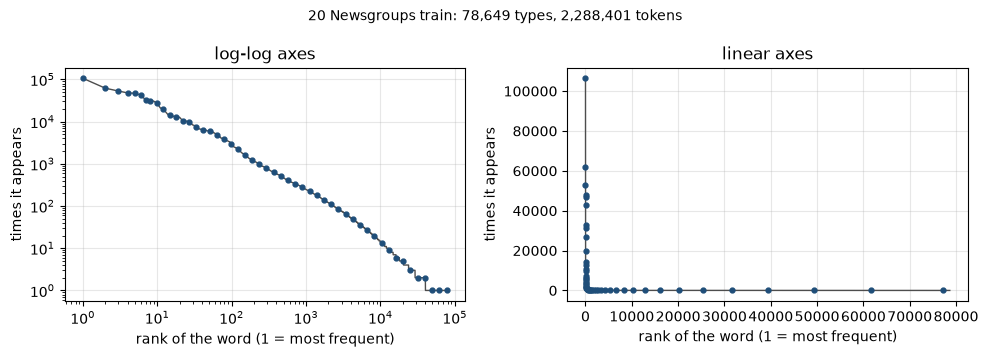

In [15]:
print("top 10:", counts.most_common(10), "\n")
vs_book("count of the tenth-ranked word", int(freqs[9]), 26_985)
vs_book("alpha=1 prediction, nearest 100", round(freqs[0] / 10, -2), 10_600, "{:,.0f}")

# the 50 (rank, count) pairs the chapter's Zipf widget plots
widget = [[1,106425],[2,62043],[3,53106],[4,47904],[5,46982],[6,42709],
  [7,32582],[8,31122],[10,26985],[12,19968],[15,14465],[18,12849],[22,10623],
  [27,9594],[33,7386],[41,6359],[51,5877],[63,4832],[78,3949],[97,3027],
  [121,2227],[151,1611],[188,1238],[235,972],[293,779],[366,625],[457,511],
  [571,405],[713,337],[891,276],[1113,221],[1391,178],[1738,139],[2172,109],
  [2715,84],[3393,65],[4241,49],[5301,36],[6626,27],[8282,19],[10352,13],
  [12940,9],[16175,6],[20218,5],[25272,3],[31590,2],[39487,2],[49358,1],
  [61697,1],[77121,1]]
same = sum(int(freqs[r - 1]) == f for r, f in widget)
print(f"\nwidget sample points reproduced: {same} of {len(widget)}")

ranks = np.arange(1, len(freqs) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, scale in zip(axes, ["log", "linear"]):
    ax.plot(ranks, freqs, lw=1, color="0.3")
    ax.plot([r for r, _ in widget], [f for _, f in widget], "o", ms=3.5, color="#1F4E79")
    ax.set_xscale(scale)
    ax.set_yscale(scale)
    ax.set_xlabel("rank of the word (1 = most frequent)")
    ax.set_ylabel("times it appears")
    ax.set_title("log-log axes" if scale == "log" else "linear axes")
    ax.grid(alpha=0.3)
fig.suptitle(f"20 Newsgroups train: {len(counts):,} types, {len(tokens):,} tokens", fontsize=10)
fig.tight_layout()
plt.show()

**Reading it.** On log-log axes the curve is close to a straight line, with the flatter
head the chapter describes. On linear axes it looks like a single spike and a flat line,
and the flat line is where almost all of the vocabulary lives.

### Back to the stop word callout

The chapter's warning in the normalization section: on this corpus, `scikit-learn`'s
English stop word list has 318 entries, which are 0.4% of the vocabulary and 43.9% of all
tokens. The cell reads "vocabulary" and "tokens" as the 78,649 types and 2,288,401 tokens
above.

In [16]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_tokens = sum(counts[w] for w in ENGLISH_STOP_WORDS)
vs_book("entries in the English stop word list", len(ENGLISH_STOP_WORDS), 318)
vs_book("share of the vocabulary, %", 100 * len(ENGLISH_STOP_WORDS) / len(counts), 0.4, "{:.1f}")
vs_book("share of all tokens, %", 100 * stop_tokens / len(tokens), 43.9, "{:.1f}")
present = sum(w in counts for w in ENGLISH_STOP_WORDS)
print(f"\n{present} of the 318 entries actually occur in this corpus "
      f"({100 * present / len(counts):.1f}% of the vocabulary as well)")

entries in the English stop word list  this run       318   book       318   same as the book
share of the vocabulary, %             this run       0.4   book       0.4   same as the book
share of all tokens, %                 this run      43.9   book      43.9   same as the book

311 of the 318 entries actually occur in this corpus (0.4% of the vocabulary as well)


### If you ever need the exponent, do not fit it with a regression

The chapter's callout gives three reasons why a least-squares slope on a log-log
rank-frequency plot is the standard way to get a wrong power-law exponent. The third is
that every point in the long, noisy tail counts as much as the well-estimated head. The
published fix is maximum likelihood with a fitted lower cutoff $x_{\min}$, plus a
Kolmogorov–Smirnov goodness-of-fit test (Clauset, Shalizi and Newman, 2009, in the
chapter's references).

**This cell is not in the book.** It is a small demonstration of that argument, in two
parts:

1. **Real data, no ground truth.** The least-squares exponent on this corpus, fitted over
   different ranges of ranks.
2. **Synthetic data, known answer.** Draw 2,288,401 tokens (this corpus's size) from a
   vocabulary of 2,000,000 types whose probabilities follow $r^{-1}$ exactly, so the true
   $\alpha$ is 1. Then fit it both ways. The maximum-likelihood fit works on the counts
   themselves: a rank exponent $\alpha$ corresponds to counts distributed as
   $P(f) \propto f^{-\gamma}$ with $\gamma = 1 + 1/\alpha$, so the fit estimates $\gamma$ for
   counts at or above $x_{\min}$ (using the Hurwitz zeta function for the discrete
   normalizer) and picks the $x_{\min}$ with the smallest KS distance.

As the chapter says, nothing else in the chapter depends on the exact value.

In [17]:
from scipy.optimize import minimize_scalar
from scipy.special import zeta


def ols_exponent(freqs, lo=1, hi=None):
    """Minus the least-squares slope of log(count) on log(rank), over ranks lo..hi."""
    f = np.sort(freqs)[::-1]
    r = np.arange(1, len(f) + 1)
    keep = (r >= lo) & (r <= (hi or len(f)))
    return -np.polyfit(np.log(r[keep]), np.log(f[keep]), 1)[0]


def power_law_mle(x, candidates):
    """Discrete power-law fit P(x) ~ x^-gamma for x >= xmin; xmin chosen by the smallest KS distance."""
    best = None
    for xmin in candidates:
        tail = np.sort(x[x >= xmin])
        n, log_sum = len(tail), np.log(tail).sum()
        gamma = minimize_scalar(lambda g: g * log_sum + n * np.log(zeta(g, xmin)),
                                bounds=(1.01, 4), method="bounded").x
        values, first = np.unique(tail, return_index=True)
        ks = np.abs((1 - first / n) - zeta(gamma, values) / zeta(gamma, xmin)).max()
        if best is None or ks < best["KS"]:
            best = {"gamma": gamma, "xmin": int(xmin), "KS": ks, "n in tail": n}
    return best


print("1. 20 Newsgroups, least squares on log-log rank-frequency")
for label, lo, hi in [("ranks 1-10", 1, 10), ("ranks 1-1,000", 1, 1000),
                      ("ranks 1,000 and beyond", 1000, None), ("all ranks", 1, None)]:
    print(f"   {label:<24} alpha = {ols_exponent(freqs, lo, hi):.2f}")

rng = np.random.default_rng(42)
V = 2_000_000
p = 1.0 / np.arange(1, V + 1)
p /= p.sum()
sample_counts = np.bincount(rng.choice(V, size=len(tokens), p=p))
synthetic = sample_counts[sample_counts > 0]

print(f"\n2. synthetic corpus with true alpha = 1: {len(synthetic):,} types seen, "
      f"{int((synthetic == 1).sum()):,} of them once")
print(f"   least squares, all ranks        alpha = {ols_exponent(synthetic):.2f}")
print(f"   least squares, ranks 1-1,000    alpha = {ols_exponent(synthetic, 1, 1000):.2f}")
fit = power_law_mle(synthetic, range(1, 200))
print(f"   maximum likelihood              gamma = {fit['gamma']:.3f} -> alpha = 1/(gamma-1) = "
      f"{1 / (fit['gamma'] - 1):.2f}   (xmin = {fit['xmin']}, KS = {fit['KS']:.4f}, "
      f"{fit['n in tail']:,} types in the fitted tail)")

1. 20 Newsgroups, least squares on log-log rank-frequency
   ranks 1-10               alpha = 0.55
   ranks 1-1,000            alpha = 1.01
   ranks 1,000 and beyond   alpha = 1.42
   all ranks                alpha = 1.38

2. synthetic corpus with true alpha = 1: 460,751 types seen, 314,642 of them once
   least squares, all ranks        alpha = 0.74
   least squares, ranks 1-1,000    alpha = 1.00


   maximum likelihood              gamma = 2.026 -> alpha = 1/(gamma-1) = 0.98   (xmin = 9, KS = 0.0042, 18,853 types in the fitted tail)


**Reading it.** On the real corpus the least-squares "exponent" depends on which ranks you
let in: well below 1 for the ten most frequent words, about 1 for the top thousand, and
well above 1 for the tail. None of these is *the* exponent. On the synthetic corpus, where
the answer is known to be 1, least squares over all ranks misses it badly, because the
hundreds of thousands of tail points, most of them counts of 1 or 2, outvote the head. The maximum-likelihood fit, with its lower
cutoff chosen from the data, lands close to 1.

Least squares over the head alone also gets close on the synthetic data, but only because
we knew the answer and could see which range to pick. On real data you do not. The full
recipe also includes a goodness-of-fit test that this cell does not run; take the shape
as the lesson, as the chapter does.

### Heaps' law

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#sec-text-as-data-heaps). Count the distinct types as you walk
through the corpus. The code is the chapter's. **The chapter does not print its output**,
only that $\beta$ is typically between 0.4 and 0.6, so there is no book value to compare
with here.

In [18]:
import numpy as np

seen, curve = set(), []
for i, tok in enumerate(tokens, 1):
    seen.add(tok)
    if i % 10_000 == 0:
        curve.append((i, len(seen)))

N, V = np.array(curve).T
beta, logK = np.polyfit(np.log(N), np.log(V), 1)
print(f"|V| ~ {np.exp(logK):.1f} * N^{beta:.3f}")

print(f"\nbeta in the chapter's typical range 0.4-0.6: {0.4 <= beta <= 0.6}")
print(f"new types in the first 10,000 tokens: {V[0]:,}; in the last 10,000: {V[-1] - V[-2]:,}")

|V| ~ 16.5 * N^0.580

beta in the chapter's typical range 0.4-0.6: True
new types in the first 10,000 tokens: 2,821; in the last 10,000: 181


**Reading it.** The exponent is below 1, so the curve keeps rising without reaching a
ceiling while its slope shrinks. The last line puts the chapter's highlighted sentence in
numbers: new words keep arriving at the end of the corpus, only more slowly than at the
start.

### Always look at your top-50 list

The chapter's callout: the *second* most frequent token in this corpus is `'ax`, and it is
not a word. The chapter gives its count, the number of documents it appears in, and the
size of the largest single contribution. The last check uses `scikit-learn`'s default
`token_pattern`, under which the chapter says the same junk surfaces as plain `ax`.

In [19]:
per_doc = [Counter(re.findall(r"[a-z']+", d.lower()))["'ax"] for d in docs]
ax_docs = [c for c in per_doc if c > 0]

vs_book("second most frequent token", counts.most_common(2)[1][0], "'ax", "{}")
vs_book("its count", counts["'ax"], 62_043)
vs_book("documents containing it", len(ax_docs), 13)
vs_book("share of documents, %", 100 * len(ax_docs) / len(docs), 0.1, "{:.1f}")
vs_book("largest single-document count", max(ax_docs), 11_147)

from sklearn.feature_extraction.text import CountVectorizer

cv_default = CountVectorizer().fit(docs)
totals = np.asarray(cv_default.transform(docs).sum(axis=0)).ravel()
names = cv_default.get_feature_names_out()
top = np.argsort(-totals, kind="stable")[:5]
print("\ntop five under the default token_pattern:", [(names[j], int(totals[j])) for j in top])

second most frequent token             this run       'ax   book       'ax   same as the book
its count                              this run    62,043   book    62,043   same as the book
documents containing it                this run        13   book        13   same as the book
share of documents, %                  this run       0.1   book       0.1   same as the book
largest single-document count          this run    11,147   book    11,147   same as the book



top five under the default token_pattern: [('the', 106381), ('ax', 62387), ('to', 53090), ('of', 46953), ('and', 42704)]


**Reading it.** Term frequency ranks `'ax` second in the language; document frequency says
it appears in about 0.1% of documents. That gap between *appears often* and *appears in
many places* is what the next section is built on. And the leading apostrophe is the
regex's doing: under the default `token_pattern`, `ax` is still second, with a slightly
different count, because the tokenizer cuts the same junk differently.

## 3. How a word becomes a vector

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#sec-text-as-data-vectors). Four short maintenance logs, taken
all the way from strings to vectors you can compute distances on, with every intermediate
number shown.

### Step 1: the vocabulary is just an index

In [20]:
record()
corpus = [
    "the pump failed",           # d1
    "the pump was replaced",     # d2
    "the valve failed",          # d3
    "the seal leak was repaired", # d4
]

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X = cv.fit_transform(corpus)
print(cv.get_feature_names_out())
compare_with_book("""
['failed' 'leak' 'pump' 'repaired' 'replaced' 'seal' 'the' 'valve' 'was']
""")

['failed' 'leak' 'pump' 'repaired' 'replaced' 'seal' 'the' 'valve' 'was']



-> same as the book, line for line (1 lines)


### Steps 2 and 3: one-hot vectors, and a document as their sum

The chapter prints these outputs without the code; the cells are our reading. **What to
look at:** the dot product of two distinct one-hot vectors is always zero, so under this
encoding every word is orthogonal to every other word.

In [21]:
vocab = list(cv.get_feature_names_out())
one_hot = lambda word: (np.array(vocab) == word).astype(int)

record()
print(f"index of 'pump': {cv.vocabulary_['pump']}")
print(f"one-hot: {one_hot('pump')}")
compare_with_book("""
index of 'pump': 2
one-hot: [0 0 1 0 0 0 0 0 0]
""")

record()
print(f"pump  : {one_hot('pump')}")
print(f"valve : {one_hot('valve')}")
print("        ------------------- multiply position by position")
print(f"        {one_hot('pump') * one_hot('valve')}  -> sum = {one_hot('pump') @ one_hot('valve')}")
compare_with_book("""
pump  : [0 0 1 0 0 0 0 0 0]
valve : [0 0 0 0 0 0 0 1 0]
        ------------------- multiply position by position
        [0 0 0 0 0 0 0 0 0]  -> sum = 0
""")

index of 'pump': 2
one-hot: [0 0 1 0 0 0 0 0 0]



-> same as the book, line for line (2 lines)
pump  : [0 0 1 0 0 0 0 0 0]
valve : [0 0 0 0 0 0 0 1 0]
        ------------------- multiply position by position
        [0 0 0 0 0 0 0 0 0]  -> sum = 0



-> same as the book, line for line (4 lines)


In [22]:
analyzer = cv.build_analyzer()
d1_tokens = analyzer(corpus[0])

record()
print(f"d1 tokens: {d1_tokens}")
print(f"d1 vector: {sum(one_hot(t) for t in d1_tokens)}")
compare_with_book("""
d1 tokens: ['the', 'pump', 'failed']
d1 vector: [1 0 1 0 0 0 1 0 0]
""")
print(f"same as CountVectorizer's row for d1: {bool((X[0].toarray()[0] == sum(one_hot(t) for t in d1_tokens)).all())}\n")

record()
counts_matrix = X.toarray()
print(f"{'':<8}" + "".join(f"{d:>4}" for d in ["d1", "d2", "d3", "d4"]))
for j, term in enumerate(vocab):
    print(f"{term:<8}" + "".join(f"{v:>4}" for v in counts_matrix[:, j]))
compare_with_book("""
          d1  d2  d3  d4
failed     1   0   1   0
leak       0   0   0   1
pump       1   1   0   0
repaired   0   0   0   1
replaced   0   1   0   0
seal       0   0   0   1
the        1   1   1   1
valve      0   0   1   0
was        0   1   0   1
""")

d1 tokens: ['the', 'pump', 'failed']
d1 vector: [1 0 1 0 0 0 1 0 0]



-> same as the book, line for line (2 lines)
same as CountVectorizer's row for d1: True

          d1  d2  d3  d4
failed     1   0   1   0
leak       0   0   0   1
pump       1   1   0   0
repaired   0   0   0   1
replaced   0   1   0   0
seal       0   0   0   1
the        1   1   1   1
valve      0   0   1   0
was        0   1   0   1



-> same as the book, line for line (10 lines)


### Step 4: counts are the wrong numbers

`scikit-learn`'s smoothed inverse document frequency:

$$\mathrm{idf}(t) = \ln\!\left(\frac{1 + n}{1 + \mathrm{df}(t)}\right) + 1$$

The first three lines of code are the chapter's. The chapter prints the table below them
without the printing code, and it names `TfidfVectorizer` without showing the call that
makes `T`; both are our reading. `T` is used again in steps 5 and 6.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

n = len(corpus)
df = (X.toarray() > 0).sum(axis=0)
idf_manual = np.log((1 + n) / (1 + df)) + 1

tfidf = TfidfVectorizer()
T = tfidf.fit_transform(corpus)

record()
print(f"{'':<8}{'df':>4}{'idf':>8}")
for term, d, w in zip(vocab, df, idf_manual):
    print(f"{term:<8}{d:>4}{w:>8.4f}")
print()
with np.printoptions(precision=4):
    print(f"sklearn idf_: {tfidf.idf_}")
print(f"max abs diff vs manual: {np.abs(tfidf.idf_ - idf_manual).max()}")
compare_with_book("""
          df     idf
failed     2  1.5108
leak       1  1.9163
pump       2  1.5108
repaired   1  1.9163
replaced   1  1.9163
seal       1  1.9163
the        4  1.0000
valve      1  1.9163
was        2  1.5108

sklearn idf_: [1.5108 1.9163 1.5108 1.9163 1.9163 1.9163 1. 1.9163 1.5108]
max abs diff vs manual: 0.0
""")

          df     idf
failed     2  1.5108
leak       1  1.9163
pump       2  1.5108
repaired   1  1.9163
replaced   1  1.9163
seal       1  1.9163
the        4  1.0000
valve      1  1.9163
was        2  1.5108

sklearn idf_: [1.5108 1.9163 1.5108 1.9163 1.9163 1.9163 1.     1.9163 1.5108]
max abs diff vs manual: 0.0



-> same values as the book (13 lines); only the spacing differs


**On the real corpus the spread is much larger.** The chapter prints five words from 20
Newsgroups, without the code. **Our reading:** document frequencies over the same
`[a-z']+` tokens as section 2, and the smoothed formula with $n$ = 11,314. That reading
reproduces every digit. The cell then repeats the count with `scikit-learn`'s default
`token_pattern`, to show how a tokenizer choice moves the counts.

In [24]:
doc_freq = Counter()
for d in docs:
    doc_freq.update(set(re.findall(r"[a-z']+", d.lower())))
N_docs = len(docs)

record()
for w in ["the", "is", "car", "encryption", "gravitational"]:
    idf_w = np.log((1 + N_docs) / (1 + doc_freq[w])) + 1
    print(f"{w:<14} df={doc_freq[w]:>6}  df/N={doc_freq[w] / N_docs:6.3f}  idf={idf_w:5.2f}")
compare_with_book("""
the            df=  9477  df/N= 0.838  idf= 1.18
is             df=  7034  df/N= 0.622  idf= 1.48
car            df=   394  df/N= 0.035  idf= 4.35
encryption     df=   169  df/N= 0.015  idf= 5.20
gravitational  df=     8  df/N= 0.001  idf= 8.14
""")

default_df = np.asarray((cv_default.transform(docs) > 0).sum(axis=0)).ravel()
print("\nwith the default token_pattern instead:",
      {w: int(default_df[cv_default.vocabulary_[w]]) for w in ["the", "is", "car", "encryption", "gravitational"]})

the            df=  9477  df/N= 0.838  idf= 1.18
is             df=  7034  df/N= 0.622  idf= 1.48
car            df=   394  df/N= 0.035  idf= 4.35
encryption     df=   169  df/N= 0.015  idf= 5.20
gravitational  df=     8  df/N= 0.001  idf= 8.14



-> same as the book, line for line (5 lines)



with the default token_pattern instead: {'the': 9475, 'is': 7028, 'car': 396, 'encryption': 169, 'gravitational': 8}


The chapter's IDF explorer lets you drag a word's document share and watch its weight. The
static version: the same curve for $n$ = 11,314, with the five words above marked.

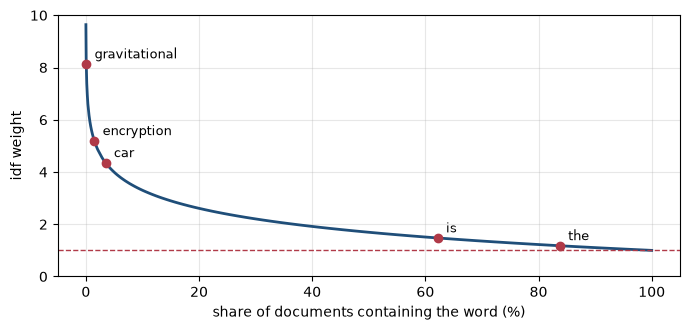

In [25]:
share_axis = np.linspace(1 / N_docs, 1, 2000)
idf_axis = np.log((1 + N_docs) / (1 + np.maximum(1, np.round(share_axis * N_docs)))) + 1

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(100 * share_axis, idf_axis, color="#1F4E79", lw=2)
ax.axhline(1, color="#B03A48", ls="--", lw=1)
for w in ["the", "is", "car", "encryption", "gravitational"]:
    s = doc_freq[w] / N_docs
    y = np.log((1 + N_docs) / (1 + doc_freq[w])) + 1
    ax.plot(100 * s, y, "o", color="#B03A48")
    ax.annotate(w, (100 * s, y), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("share of documents containing the word (%)")
ax.set_ylabel("idf weight")
ax.set_ylim(0, 10)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**Reading it.** The dashed line is the floor at idf = 1: a word in every document is
down-weighted, never deleted. Above about 20% the curve is nearly flat; all the action is in
the first few percent, where content words live.

### Step 5: multiply, then normalize

For d1 (`the pump failed`): multiply the counts by the IDF weights, divide by the vector's
length, and compare with `TfidfVectorizer`'s row. The printing code is our reading.

In [26]:
counts_d1 = X.toarray()[0]
weighted = counts_d1 * idf_manual
norm = np.linalg.norm(weighted)

record()
with np.printoptions(precision=4):
    print(f"counts        : {counts_d1}")
    print(f"times idf     : {weighted}")
    print(f"l2 norm       : {norm:.4f}")
    print(f"normalized    : {weighted / norm}")
    print(f"sklearn row d1: {T.toarray()[0]}")
compare_with_book("""
counts        : [1 0 1 0 0 0 1 0 0]
times idf     : [1.5108 0. 1.5108 0. 0. 0. 1. 0. 0.]
l2 norm       : 2.3591
normalized    : [0.6404 0. 0.6404 0. 0. 0. 0.4239 0. 0.]
sklearn row d1: [0.6404 0. 0.6404 0. 0. 0. 0.4239 0. 0.]
""")
print()
full = f"{norm:.12f}"
print(f"{'norm at full precision':<38} this run {full}   book 2.35906509...   "
      f"{'same as the book' if full.startswith('2.35906509') else 'DIFFERS from the book'}")
vs_book("max abs diff, hand vs TfidfVectorizer", np.abs(weighted / norm - T.toarray()[0]).max(), 0.0, "{:.1e}")

counts        : [1 0 1 0 0 0 1 0 0]
times idf     : [1.5108 0.     1.5108 0.     0.     0.     1.     0.     0.    ]
l2 norm       : 2.3591
normalized    : [0.6404 0.     0.6404 0.     0.     0.     0.4239 0.     0.    ]
sklearn row d1: [0.6404 0.     0.6404 0.     0.     0.     0.4239 0.     0.    ]



-> same values as the book (5 lines); only the spacing differs

norm at full precision                 this run 2.359065096782   book 2.35906509...   same as the book
max abs diff, hand vs TfidfVectorizer  this run   0.0e+00   book   0.0e+00   same as the book


The chapter's document-term matrix widget prints the whole TF-IDF matrix to three decimals.
The same matrix from this run:

In [27]:
widget_tfidf = np.array([
  [0.640,0.000,0.640,0.000,0.000,0.000,0.424,0.000,0.000],
  [0.000,0.000,0.497,0.000,0.631,0.000,0.329,0.000,0.497],
  [0.573,0.000,0.000,0.000,0.000,0.000,0.379,0.727,0.000],
  [0.000,0.507,0.000,0.507,0.000,0.507,0.264,0.000,0.400]])

print(f"{'':<4}" + "".join(f"{t:>9}" for t in vocab))
for name, row in zip(["d1", "d2", "d3", "d4"], T.toarray()):
    print(f"{name:<4}" + "".join(f"{v:>9.3f}" if v else f"{'.':>9}" for v in row))
matches = int((T.toarray().round(3) == widget_tfidf).sum())
print(f"\ncells equal to the widget's values at three decimals: {matches} of {widget_tfidf.size}")

       failed     leak     pump repaired replaced     seal      the    valve      was
d1      0.640        .    0.640        .        .        .    0.424        .        .
d2          .        .    0.497        .    0.631        .    0.329        .    0.497
d3      0.573        .        .        .        .        .    0.379    0.727        .
d4          .    0.507        .    0.507        .    0.507    0.264        .    0.400

cells equal to the widget's values at three decimals: 36 of 36


**Reading it.** In every row `the` gets the smallest non-zero weight, and `valve`, which
only d3 contains, is the largest cell in the matrix.

### Step 6: comparing documents with cosine similarity

On unit-length vectors the cosine is just the dot product, and only positions where both
vectors are non-zero contribute. The chapter works d1 against d3 by hand: two live terms,
`failed` and `the`.

In [28]:
Td = T.toarray()
j_failed, j_the = cv.vocabulary_["failed"], cv.vocabulary_["the"]
part_failed = Td[0, j_failed] * Td[2, j_failed]
part_the = Td[0, j_the] * Td[2, j_the]
cos13 = Td[0] @ Td[2]

print(f"cos(d1, d3) = {Td[0, j_failed]:.4f} x {Td[2, j_failed]:.4f} + {Td[0, j_the]:.4f} x {Td[2, j_the]:.4f}"
      f" = {part_failed:.4f} + {part_the:.4f} = {cos13:.3f}\n")
vs_book("d3's weight on failed", Td[2, j_failed], 0.5729, "{:.4f}")
vs_book("d3's weight on the", Td[2, j_the], 0.3792, "{:.4f}")
vs_book("failed's contribution", part_failed, 0.3669, "{:.4f}")
vs_book("the's contribution", part_the, 0.1607, "{:.4f}")
vs_book("cos(d1, d3)", cos13, 0.528, "{:.3f}")
vs_book("share supplied by failed, %", 100 * part_failed / cos13, 70, "{:.0f}")
vs_book("share supplied by the, %", 100 * part_the / cos13, 30, "{:.0f}")

cos(d1, d3) = 0.6404 x 0.5729 + 0.4239 x 0.3792 = 0.3669 + 0.1607 = 0.528

d3's weight on failed                  this run    0.5729   book    0.5729   same as the book
d3's weight on the                     this run    0.3792   book    0.3792   same as the book
failed's contribution                  this run    0.3669   book    0.3669   same as the book
the's contribution                     this run    0.1607   book    0.1607   same as the book
cos(d1, d3)                            this run     0.528   book     0.528   same as the book
share supplied by failed, %            this run        70   book        70   same as the book
share supplied by the, %               this run        30   book        30   same as the book


The chapter's code for the full matrix is one line, `cosine_similarity(T).round(3)`; the
labelled layout it prints, and the raw-count panel, are our reading.

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

S_tfidf = cosine_similarity(T).round(3)
S_counts = cosine_similarity(X).round(3)
names4 = ["d1", "d2", "d3", "d4"]


def show(S, label):
    print("  " + "".join(f"{d:>7}" for d in names4) + f"          <- {label}")
    for name, row in zip(names4, S):
        print(name + "".join(f"{v:7.3f}" for v in row))


record()
show(S_tfidf, "TF-IDF")
print()
show(S_counts, "raw counts")
compare_with_book("""
       d1     d2     d3     d4          <- TF-IDF
d1  1.000  0.458  0.528  0.112
d2  0.458  1.000  0.125  0.286
d3  0.528  0.125  1.000  0.100
d4  0.112  0.286  0.100  1.000

       d1     d2     d3     d4          <- raw counts
d1  1.000  0.577  0.667  0.258
d2  0.577  1.000  0.289  0.447
d3  0.667  0.289  1.000  0.258
d4  0.258  0.447  0.258  1.000
""")

print("\nhow much each pair drops, and what the two documents share")
sets = [set(analyzer(d)) for d in corpus]
for i in range(4):
    for j in range(i + 1, 4):
        shared = sorted(sets[i] & sets[j])
        print(f"  d{i + 1}-d{j + 1}  {S_counts[i, j]:.3f} -> {S_tfidf[i, j]:.3f}  "
              f"(drop {S_counts[i, j] - S_tfidf[i, j]:.3f})  shared: {shared}")

       d1     d2     d3     d4          <- TF-IDF
d1  1.000  0.458  0.528  0.112
d2  0.458  1.000  0.125  0.286
d3  0.528  0.125  1.000  0.100
d4  0.112  0.286  0.100  1.000

       d1     d2     d3     d4          <- raw counts
d1  1.000  0.577  0.667  0.258
d2  0.577  1.000  0.289  0.447
d3  0.667  0.289  1.000  0.258
d4  0.258  0.447  0.258  1.000



-> same as the book, line for line (11 lines)

how much each pair drops, and what the two documents share
  d1-d2  0.577 -> 0.458  (drop 0.119)  shared: ['pump', 'the']
  d1-d3  0.667 -> 0.528  (drop 0.139)  shared: ['failed', 'the']
  d1-d4  0.258 -> 0.112  (drop 0.146)  shared: ['the']
  d2-d3  0.289 -> 0.125  (drop 0.164)  shared: ['the']
  d2-d4  0.447 -> 0.286  (drop 0.161)  shared: ['the', 'was']
  d3-d4  0.258 -> 0.100  (drop 0.158)  shared: ['the']


**Reading it.** Every pair drops. The four largest drops are the pairs whose common ground
is only `the`, or `the` and `was`. Both of those words are on `scikit-learn`'s English stop
word list. The two smallest drops are the pairs that share a content word, `pump` or
`failed`. And d1 against d4, which share only `the`, falls from 0.26 to 0.11. A cosine is
the cosine of an angle between two vectors, not a percentage of semantic similarity.

### Why cosine and not Euclidean distance

The chapter's figure uses three documents over two words: A = (2, 1), B = (20, 10), the same
report ten times longer, and C = (1, 4), a different topic. The cell recomputes every number
on the figure and in the intuition check under it.

In [30]:
A, B, C = np.array([2.0, 1.0]), np.array([20.0, 10.0]), np.array([1.0, 4.0])
unit = lambda v: v / np.linalg.norm(v)
a, b, c = unit(A), unit(B), unit(C)
cos_ac = a @ c

vs_book("Euclidean ||A - C||", np.linalg.norm(A - C), 3.16, "{:.2f}")
vs_book("Euclidean ||A - B||", np.linalg.norm(A - B), 20.12, "{:.2f}")
ratio = np.linalg.norm(A - B) / np.linalg.norm(A - C)
print(f"{'times closer A is to C than to B':<38} this run {ratio:>9.2f}   book  'more than six'   {'consistent' if ratio > 6 else 'NOT consistent'}")
vs_book("angle between a and c, degrees", np.degrees(np.arccos(cos_ac)), 49.4, "{:.1f}")
vs_book("cos(a, c)", cos_ac, 0.651, "{:.3f}")
vs_book("||a - c||^2 = 2 - 2 cos", 2 - 2 * cos_ac, 0.698, "{:.3f}")
vs_book("||a - c||", np.sqrt(2 - 2 * cos_ac), 0.836, "{:.3f}")
print(f"\nafter normalization: a and b are the same point: {np.allclose(a, b)}; "
      f"||a - c|| measured directly = {np.linalg.norm(a - c):.3f}")
print(f"A's nearest neighbour  by raw Euclidean distance: {'C' if np.linalg.norm(A - C) < np.linalg.norm(A - B) else 'B'}"
      f"   by cosine: {'B' if a @ b > a @ c else 'C'}")

Euclidean ||A - C||                    this run      3.16   book      3.16   same as the book
Euclidean ||A - B||                    this run     20.12   book     20.12   same as the book
times closer A is to C than to B       this run      6.36   book  'more than six'   consistent
angle between a and c, degrees         this run      49.4   book      49.4   same as the book
cos(a, c)                              this run     0.651   book     0.651   same as the book
||a - c||^2 = 2 - 2 cos                this run     0.698   book     0.698   same as the book
||a - c||                              this run     0.836   book     0.836   same as the book

after normalization: a and b are the same point: True; ||a - c|| measured directly = 0.836
A's nearest neighbour  by raw Euclidean distance: C   by cosine: B


**Where $2 - 2\cos$ comes from.** For unit vectors,
$\lVert a-b \rVert^2 = a \cdot a - 2\,a \cdot b + b \cdot b = 2 - 2\cos(a,b)$. The
cell checks the identity on all pairs of the four TF-IDF rows, then checks the consequence
the chapter draws: nearest-neighbour search by Euclidean distance and by cosine return the
same ranked list, provided the vectors were normalized first.

In [31]:
sq_dist = ((Td[:, None, :] - Td[None, :, :]) ** 2).sum(axis=-1)
S = cosine_similarity(T)
print(f"max |squared distance - (2 - 2 cos)| over all 16 pairs: {np.abs(sq_dist - (2 - 2 * S)).max():.1e}")

same_rankings = all(
    list(np.argsort(sq_dist[i], kind="stable")) == list(np.argsort(-S[i], kind="stable"))
    for i in range(4))
print(f"every document's neighbours in the same order under both: {same_rankings}")

max |squared distance - (2 - 2 cos)| over all 16 pairs: 2.2e-16
every document's neighbours in the same order under both: True


## 4. What bag-of-words cannot do

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#sec-text-as-data-limits). The chapter prints the two sentences
below and their outputs; the printing code is our reading.

**It cannot represent word order.** Two reports naming opposite pieces of failed equipment:

In [32]:
pair = ["the pump failed and the valve is fine",
        "the valve failed and the pump is fine"]

cv_pair = CountVectorizer()
P = cv_pair.fit_transform(pair).toarray()

record()
print(f"vocabulary: [{','.join(repr(t) for t in cv_pair.get_feature_names_out())}]")
print(f"row 1: {P[0]}")
print(f"row 2: {P[1]}")
print(f"vectors identical: {bool((P[0] == P[1]).all())}")
print(f"cosine similarity: {cosine_similarity(P)[0, 1].round(3)}")
compare_with_book("""
vocabulary: ['and','failed','fine','is','pump','the','valve']
row 1: [1 1 1 1 1 2 1]
row 2: [1 1 1 1 1 2 1]
vectors identical: True
cosine similarity: 1.0
""")

vocabulary: ['and','failed','fine','is','pump','the','valve']
row 1: [1 1 1 1 1 2 1]
row 2: [1 1 1 1 1 2 1]
vectors identical: True
cosine similarity: 1.0



-> same as the book, line for line (5 lines)


**n-grams buy back a little.** Pairs of adjacent words instead of single words. **Our
reading:** bigrams only (`ngram_range=(2, 2)`) with raw counts, like the unigram cell above.
The same bigrams under TF-IDF give a different cosine, printed below the comparison.

In [33]:
cv_bi = CountVectorizer(ngram_range=(2, 2))
P2 = cv_bi.fit_transform(pair)
bigrams = [repr(t) for t in cv_bi.get_feature_names_out()]

record()
print(f"bigram vocabulary: [{','.join(bigrams[:4])},")
print(f"{'':20}{','.join(bigrams[4:])}]")
print(f"cosine similarity: {cosine_similarity(P2)[0, 1]:.3f}")
print(f"vocabulary size: unigrams {len(cv_pair.vocabulary_)} -> bigrams {len(cv_bi.vocabulary_)}")
compare_with_book("""
bigram vocabulary: ['and the','failed and','is fine','pump failed',
                    'pump is','the pump','the valve','valve failed','valve is']
cosine similarity: 0.714
vocabulary size: unigrams 7 -> bigrams 9
""")
print(f"\nthe same bigrams under TF-IDF: cosine {cosine_similarity(TfidfVectorizer(ngram_range=(2, 2)).fit_transform(pair))[0, 1]:.3f}")

bigram vocabulary: ['and the','failed and','is fine','pump failed',
                    'pump is','the pump','the valve','valve failed','valve is']
cosine similarity: 0.714
vocabulary size: unigrams 7 -> bigrams 9



-> same as the book, line for line (4 lines)

the same bigrams under TF-IDF: cosine 0.559


**It cannot represent the scope of negation.** Two sentences with opposite operational
meaning. The last line checks the chapter's warning that with a stop word list containing
*no* they become 100% similar.

In [34]:
neg = ["no leak was found", "a leak was found"]
cv_neg = CountVectorizer()
N_counts = cv_neg.fit_transform(neg)

record()
print(f'"{neg[0]}"  vs  "{neg[1]}"')
print('vocabulary (the default token_pattern drops the one-letter "a"):')
print(f"    {list(cv_neg.get_feature_names_out())}")
print(f"raw counts  ->  cosine {cosine_similarity(N_counts)[0, 1]:.3f}")
print(f"TF-IDF      ->  cosine {cosine_similarity(TfidfVectorizer().fit_transform(neg))[0, 1]:.3f}")
compare_with_book("""
"no leak was found"  vs  "a leak was found"
vocabulary (the default token_pattern drops the one-letter "a"):
    ['found', 'leak', 'no', 'was']
raw counts  ->  cosine 0.866
TF-IDF      ->  cosine 0.777
""")

cv_stop = CountVectorizer(stop_words="english")
N_stop = cv_stop.fit_transform(neg)
print(f"\nwith stop_words='english': vocabulary {list(cv_stop.get_feature_names_out())}, "
      f"cosine {cosine_similarity(N_stop)[0, 1]:.3f}  ('no' in the list: {'no' in ENGLISH_STOP_WORDS})")

"no leak was found"  vs  "a leak was found"
vocabulary (the default token_pattern drops the one-letter "a"):
    ['found', 'leak', 'no', 'was']
raw counts  ->  cosine 0.866
TF-IDF      ->  cosine 0.777



-> same as the book, line for line (5 lines)

with stop_words='english': vocabulary ['leak'], cosine 1.000  ('no' in the list: True)


## 5. Does any of this still matter?

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#does-any-of-this-still-matter). Four newsgroups, logistic
regression, nothing tuned, six ways of turning text into features. The code is the
chapter's, with two additions: `data_home=DATA_HOME` for the cache, and one line that keeps
each fitted pipeline for the cells after it.

The chapter's status note explains why this reproduces exactly: the default `lbfgs` solver
takes no randomness, so `random_state=0` does not matter here.

**What to look at:** the six accuracies and feature counts. The data comes from the same
20 Newsgroups archive as section 2.

In [35]:
record()
start = time.perf_counter()
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

cats = ["sci.med", "sci.space", "rec.autos", "talk.politics.guns"]
drop = ("headers", "footers", "quotes")
train = fetch_20newsgroups(subset="train", categories=cats, remove=drop, data_home=DATA_HOME)
test = fetch_20newsgroups(subset="test", categories=cats, remove=drop, data_home=DATA_HOME)

setups = {
    "raw counts": CountVectorizer(),
    "counts + stop words": CountVectorizer(stop_words="english"),
    "tf-idf": TfidfVectorizer(),
    "tf-idf + stop words": TfidfVectorizer(stop_words="english"),
    "tf-idf + bigrams": TfidfVectorizer(ngram_range=(1, 2)),
    "tf-idf + sublinear tf": TfidfVectorizer(sublinear_tf=True),
}

models, accuracy = {}, {}   # (added) keep each fitted pipeline and its accuracy
for name, vec in setups.items():
    clf = make_pipeline(vec, LogisticRegression(max_iter=2000, random_state=0))
    clf.fit(train.data, train.target)
    acc = accuracy_score(test.target, clf.predict(test.data))
    models[name], accuracy[name] = clf, acc   # (added)
    print(f"{name:<24} accuracy {acc:.3f}   "
          f"features {len(clf[0].get_feature_names_out()):>7}")
compare_with_book("""
raw counts               accuracy 0.767   features   32318
counts + stop words      accuracy 0.795   features   32014
tf-idf                   accuracy 0.831   features   32318
tf-idf + stop words      accuracy 0.853   features   32014
tf-idf + bigrams         accuracy 0.819   features  249522
tf-idf + sublinear tf    accuracy 0.843   features   32318
""")
print(f"\n{len(train.data):,} training and {len(test.data):,} test documents; "
      f"all six fits took {time.perf_counter() - start:.1f} s")

raw counts               accuracy 0.767   features   32318


counts + stop words      accuracy 0.795   features   32014


tf-idf                   accuracy 0.831   features   32318


tf-idf + stop words      accuracy 0.853   features   32014


tf-idf + bigrams         accuracy 0.819   features  249522


tf-idf + sublinear tf    accuracy 0.843   features   32318



-> same as the book, line for line (6 lines)

2,327 training and 1,550 test documents; all six fits took 4.6 s


**The four lessons, and the caution.** The chapter reads four lessons out of those six
lines and then warns that they are point estimates. A single accuracy near 0.83 on 1,550
test documents carries a 95% interval of roughly ±1.9 points (the normal approximation,
$1.96\sqrt{p(1-p)/n}$), and lessons 3 and 4 each rest on a gap of 1.2.

In [36]:
features = {name: len(m[0].get_feature_names_out()) for name, m in models.items()}
gap = lambda x, y: 100 * (accuracy[x] - accuracy[y])

vs_book("train documents", len(train.data), 2_327)
vs_book("test documents", len(test.data), 1_550)
vs_book("1. tf-idf over raw counts, points", gap("tf-idf", "raw counts"), 6.4, "{:.1f}")
vs_book("2. stop words on tf-idf, points", gap("tf-idf + stop words", "tf-idf"), 2.2, "{:+.1f}")
vs_book("3. bigram feature multiplier", features["tf-idf + bigrams"] / features["tf-idf"], 7.7, "{:.1f}")
vs_book("3. tf-idf minus bigrams, points", gap("tf-idf", "tf-idf + bigrams"), 1.2, "{:.1f}")
vs_book("4. sublinear tf minus tf-idf, points", gap("tf-idf + sublinear tf", "tf-idf"), 1.2, "{:.1f}")
vs_book("95% half-width near 0.83, points", 100 * 1.96 * math.sqrt(0.83 * 0.17 / len(test.data)), 1.9, "{:.1f}")

train documents                        this run     2,327   book     2,327   same as the book
test documents                         this run     1,550   book     1,550   same as the book
1. tf-idf over raw counts, points      this run       6.4   book       6.4   same as the book
2. stop words on tf-idf, points        this run      +2.2   book      +2.2   same as the book
3. bigram feature multiplier           this run       7.7   book       7.7   same as the book
3. tf-idf minus bigrams, points        this run       1.2   book       1.2   same as the book
4. sublinear tf minus tf-idf, points   this run       1.2   book       1.2   same as the book
95% half-width near 0.83, points       this run       1.9   book       1.9   same as the book


**Reading it.** Read lessons 1 and 2 as findings and lessons 3 and 4 as *directions*, as
the chapter does: their gaps are smaller than the interval on a single accuracy. The right
instrument is a paired test such as McNemar's, which the chapter did not run (see exercise
4 below). And the chapter's warning about generalising: on Turkish product reviews,
[chapter 4](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/04-bake-off.html) measures the opposite on both counts, with bigrams giving the largest
single gain and plain counting beating TF-IDF.

### The model is readable

The chapter prints the words each class's weights point to, without the code. **Our
reading:** the highest-weighted terms per class of the best row, `tf-idf + stop words`. The
chapter lists eight words for `rec.autos` and seven for the others, so the cell compares
that many. Below the comparison, the same list from plain `tf-idf`, with the stop words
still in.

In [37]:
def top_terms(model, k=8):
    terms = model[0].get_feature_names_out()
    coef = model[1].coef_
    return {train.target_names[c]: list(terms[np.argsort(-coef[i], kind="stable")[:k]])
            for i, c in enumerate(model[1].classes_)}


book_lengths = {"rec.autos": 8, "sci.med": 7, "sci.space": 7, "talk.politics.guns": 7}
record()
for cat, words_ in top_terms(models["tf-idf + stop words"]).items():
    print(f"{cat:<20} {', '.join(words_[:book_lengths[cat]])}")
compare_with_book("""
rec.autos            car, cars, engine, ford, oil, dealer, drive, price
sci.med              msg, doctor, disease, medical, pain, patients, treatment
sci.space            space, nasa, orbit, moon, launch, earth, spacecraft
talk.politics.guns   gun, guns, weapons, fbi, law, government, firearms
""")

print("\nthe same question to plain tf-idf, stop words kept:")
for cat, words_ in top_terms(models["tf-idf"]).items():
    print(f"{cat:<20} {', '.join(words_)}")

rec.autos            car, cars, engine, ford, oil, dealer, drive, price
sci.med              msg, doctor, disease, medical, pain, patients, treatment
sci.space            space, nasa, orbit, moon, launch, earth, spacecraft
talk.politics.guns   gun, guns, weapons, fbi, law, government, firearms



-> same as the book, line for line (4 lines)

the same question to plain tf-idf, stop words kept:
rec.autos            car, cars, engine, ford, dealer, oil, my, drive
sci.med              msg, is, doctor, disease, of, medical, my, patients
sci.space            space, nasa, orbit, moon, launch, earth, spacecraft, shuttle
talk.politics.guns   gun, guns, weapons, fbi, law, government, fire, firearms


**Reading it.** The model names its own evidence in words. With stop words kept, a few
function words (`is`, `of`, `my`) also make it into the lists.

### And the engineering is hard to beat

The chapter prints the size of the TF-IDF training matrix, without the code. **Our
reading:** the default `TfidfVectorizer` on the 2,327 training documents; dense size is
8 bytes per cell; sparse size is what the CSR arrays actually hold (float64 values, int32
column indices, int32 row pointers); megabytes are $10^6$ bytes.

In [38]:
M = TfidfVectorizer().fit_transform(train.data)
dense_mb = M.shape[0] * M.shape[1] * 8 / 1e6
sparse_mb = (M.data.nbytes + M.indices.nbytes + M.indptr.nbytes) / 1e6

record()
print(f"shape: {M.shape}")
print(f"stored non-zeros: {M.nnz}")
print(f"density: {100 * M.nnz / (M.shape[0] * M.shape[1]):.3f}%")
print(f"dense float64 would need : {dense_mb:8.1f} MB")
print(f"sparse csr actually needs: {sparse_mb:8.1f} MB")
print(f"ratio: {dense_mb / sparse_mb:.0f}x")
compare_with_book("""
shape: (2327, 32318)
stored non-zeros: 234281
density: 0.312%
dense float64 would need :    601.6 MB
sparse csr actually needs:      2.8 MB
ratio: 213x
""")
print(f"\ndtypes: values {M.data.dtype}, column indices {M.indices.dtype}, row pointers {M.indptr.dtype}")

shape: (2327, 32318)
stored non-zeros: 234281
density: 0.312%
dense float64 would need :    601.6 MB
sparse csr actually needs:      2.8 MB
ratio: 213x



-> same as the book, line for line (6 lines)

dtypes: values float64, column indices int32, row pointers int32


### BM25, in code

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#where-this-is-actually-deployed). The chapter gives BM25 as a
formula, without code or numbers:

$$\mathrm{BM25}(q, d) = \sum_{t \in q} \mathrm{idf}(t) \cdot
\frac{c(t,d)\,(k_1 + 1)}{c(t,d) + k_1\!\left(1 - b + b\,\frac{|d|}{\mathrm{avgdl}}\right)}$$

**This cell is a direct transcription of that formula, not a reproduction.** It uses
Lucene's defaults $k_1 = 1.2$ and $b = 0.75$, which the chapter names. The chapter says
only that BM25's idf is "a probabilistic variant"; the cell uses the one Lucene uses,
$\ln\left(1 + \frac{n - \mathrm{df} + 0.5}{\mathrm{df} + 0.5}\right)$.

**What to look at:** the first table shows the saturation the chapter describes (the term
approaches $k_1 + 1 = 2.2$ and stops growing, like `sublinear_tf` with a ceiling). The
second shows the $b$ dial on document length. The last lines score the four maintenance logs
from section 3 for the query `pump failed`.

In [39]:
def bm25_tf(c, doc_len, avgdl, k1=1.2, b=0.75):
    """BM25's saturating term-frequency factor."""
    return c * (k1 + 1) / (c + k1 * (1 - b + b * doc_len / avgdl))


print("term frequency factor for a document of average length")
print(f"{'count c':>8} {'raw c':>7} {'1 + ln c':>9} {'BM25':>7}")
for cnt in [1, 2, 3, 5, 10, 100]:
    print(f"{cnt:>8} {cnt:>7} {1 + math.log(cnt):>9.2f} {bm25_tf(cnt, 1, 1):>7.2f}")

print("\none occurrence, in documents of different lengths")
print(f"{'|d| / avgdl':>12} {'b = 0':>7} {'b = 0.75':>9} {'b = 1':>7}")
for rel in [0.5, 1, 2, 4]:
    print(f"{rel:>12} {bm25_tf(1, rel, 1, b=0):>7.2f} {bm25_tf(1, rel, 1):>9.2f} {bm25_tf(1, rel, 1, b=1):>7.2f}")

lengths = X.toarray().sum(axis=1)
avgdl = lengths.mean()
bm25_idf = np.log(1 + (n - df + 0.5) / (df + 0.5))
query = ["pump", "failed"]
print(f"\nquery {' '.join(query)!r} over the four maintenance logs (avgdl = {avgdl})")
for i, d in enumerate(corpus):
    score = sum(bm25_idf[cv.vocabulary_[t]] * bm25_tf(X[i, cv.vocabulary_[t]], lengths[i], avgdl) for t in query)
    print(f"  d{i + 1}  {d:<28} BM25 {score:.3f}")

term frequency factor for a document of average length
 count c   raw c  1 + ln c    BM25
       1       1      1.00    1.00
       2       2      1.69    1.38
       3       3      2.10    1.57
       5       5      2.61    1.77
      10      10      3.30    1.96
     100     100      5.61    2.17

one occurrence, in documents of different lengths
 |d| / avgdl   b = 0  b = 0.75   b = 1
         0.5    1.00      1.26    1.38
           1    1.00      1.00    1.00
           2    1.00      0.71    0.65
           4    1.00      0.45    0.38

query 'pump failed' over the four maintenance logs (avgdl = 3.75)
  d1  the pump failed              BM25 1.510
  d2  the pump was replaced        BM25 0.675
  d3  the valve failed             BM25 0.755
  d4  the seal leak was repaired   BM25 0.000


**Reading it.** The count column keeps climbing and `1 + ln c` climbs more slowly, but BM25
flattens towards 2.2: the tenth occurrence adds almost nothing. With $b = 0$ document length
is ignored; with $b = 1$ one occurrence in a document twice the average length is worth
about two thirds as much. In the query, `pump` and `failed` each appear in two of the four
logs, so they get the same idf, and d3 outscores d2 only because it is shorter. d1 contains
both words and ranks first; d4 contains neither and scores zero.

## 6. Numbers from the intuition checks and interview questions

[Intuition checks](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#intuition-checks) · [Interview questions](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#interview-questions)

**Intuition check 1: `min_df`.** On the four-category training set, `min_df=5` takes the
vocabulary from 32,318 to 6,281, and the deleted columns still carry 11.6% of the token
occurrences. **Our reading:** default `CountVectorizer` on the 2,327 training documents.
The accuracy of a `min_df=5` model is exercise 4, so it is not printed here.

In [40]:
cv_train = CountVectorizer().fit(train.data)
C_train = cv_train.transform(train.data)
doc_counts = np.asarray((C_train > 0).sum(axis=0)).ravel()
occurrences = np.asarray(C_train.sum(axis=0)).ravel()
kept = doc_counts >= 5

vs_book("columns before min_df", len(doc_counts), 32_318)
vs_book("columns with min_df=5", int(kept.sum()), 6_281)
vs_book("share of columns removed, %", 100 * (1 - kept.mean()), 81, "{:.0f}")
vs_book("occurrences in removed columns, %", 100 * occurrences[~kept].sum() / occurrences.sum(), 11.6, "{:.1f}")
vs_book("CountVectorizer(min_df=5) agrees", len(CountVectorizer(min_df=5).fit(train.data).vocabulary_), 6_281)

columns before min_df                  this run    32,318   book    32,318   same as the book
columns with min_df=5                  this run     6,281   book     6,281   same as the book
share of columns removed, %            this run        81   book        81   same as the book
occurrences in removed columns, %      this run      11.6   book      11.6   same as the book


CountVectorizer(min_df=5) agrees       this run     6,281   book     6,281   same as the book


**Intuition check 5: the part number that disappeared.** The chapter prints the vocabulary
under the default `token_pattern` and under a custom one, but neither the input text nor
the custom pattern. **Our reading:** two short log lines, and a pattern that lets a token
contain inner hyphens.

In [41]:
logs = ["pump P-101 tripped", "P-102 tripped"]
custom = r"(?u)\b\w[\w-]*\w\b"

record()
print(f"default    : {list(CountVectorizer().fit(logs).get_feature_names_out())}")
print(f"custom     : {list(CountVectorizer(token_pattern=custom).fit(logs).get_feature_names_out())}")
compare_with_book("""
default    : ['101', '102', 'pump', 'tripped']
custom     : ['p-101', 'p-102', 'pump', 'tripped']
""")

default    : ['101', '102', 'pump', 'tripped']
custom     : ['p-101', 'p-102', 'pump', 'tripped']



-> same as the book, line for line (2 lines)


**The arithmetic in the interview answers.** Plain arithmetic, no data: a $10^6 \times 10^5$
document-term matrix, an all-pairs cosine matrix, the pair count for near-duplicate
detection, and the LSH banding threshold. Bytes are converted with $10^9$ per GB.

In [42]:
cells_ = 10**6 * 10**5
nnz = cells_ // 1000                      # 0.1% density
vs_book("dense 10^6 x 10^5 at 8 bytes, GB", cells_ * 8 / 1e9, 800, "{:,.0f}")
vs_book("CSR at 0.1%, 12 bytes per value, GB", nnz * 12 / 1e9, 1.2, "{:.1f}")
vs_book("saving, values and indices only", cells_ * 8 / (nnz * 12), 665, "{:,.0f}")
vs_book("saving, with int32 row pointers too", cells_ * 8 / (nnz * 12 + (10**6 + 1) * 4), 665, "{:,.0f}")
vs_book("CSR at 1% density, GB", cells_ // 100 * 12 / 1e9, 12, "{:,.0f}")
vs_book("dense cosine matrix, n = 50,000, GB", 50_000**2 * 8 / 1e9, 20, "{:,.0f}")

pairs = math.comb(10**8, 2)
vs_book("pairs among 10^8 documents", pairs, 5e15, "{:.0e}")
vs_book("days at 10^9 comparisons per second", pairs / 1e9 / 86_400, 58, "{:.0f}")

bands, rows = 16, 8
vs_book("LSH threshold (1/b)^(1/r)", (1 / bands) ** (1 / rows), 0.71, "{:.2f}")
p_candidate = lambda j: 1 - (1 - j**rows) ** bands
vs_book("P(candidate | Jaccard 0.8), %", 100 * p_candidate(0.8), 94.7, "{:.1f}")
vs_book("P(candidate | Jaccard 0.3), %", 100 * p_candidate(0.3), 0.1, "{:.1f}")

dense 10^6 x 10^5 at 8 bytes, GB       this run       800   book       800   same as the book
CSR at 0.1%, 12 bytes per value, GB    this run       1.2   book       1.2   same as the book
saving, values and indices only        this run       667   book       665   DIFFERS from the book
saving, with int32 row pointers too    this run       664   book       665   DIFFERS from the book
CSR at 1% density, GB                  this run        12   book        12   same as the book
dense cosine matrix, n = 50,000, GB    this run        20   book        20   same as the book
pairs among 10^8 documents             this run     5e+15   book     5e+15   same as the book
days at 10^9 comparisons per second    this run        58   book        58   same as the book
LSH threshold (1/b)^(1/r)              this run      0.71   book      0.71   same as the book
P(candidate | Jaccard 0.8), %          this run      94.7   book      94.7   same as the book
P(candidate | Jaccard 0.3), %          this run   

**Reading it.** Everything matches except the saving, which the chapter gives as "about
665×". 800 GB over 1.2 GB is 667×; adding the row-pointer array CSR also stores ($10^6 + 1$
four-byte integers, which "12 bytes each" leaves out) gives 664×. Neither reading rounds to
exactly 665, and both are "about 665": the point, hundreds of times smaller, stands.

## 7. Exercises

These follow [chapter 2's own exercises](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html#exercises), starting from the cells above.

1. **Tokenizer economics.** Replace the two strings in section 1c with a paragraph of your
   own technical writing in Turkish and its English translation, and count tokens under
   `cl100k_base` and `o200k_base`. Compute the cost ratio, then estimate what it does to an
   annual API bill at 100,000 requests per month. Before you trust the ratio, run the
   "how general" cell on a few of your own words: does a leading space change your answer?

2. **Break the vectorizer.** Fit a `CountVectorizer` on ten documents from your own domain
   and print `get_feature_names_out()`. Find at least two wrong tokens (a destroyed
   identifier, a merged pair, a lost unit) and fix them with `token_pattern`, the way
   section 6 fixes `P-101`. Report what changed.

3. **Derive it by hand.** Compute the TF-IDF vector for d3 (`the valve failed`) with pen and
   paper, then check it against `T.toarray()[2]` in section 3. If they disagree, the
   chapter says the cause is almost always the smoothing, the L2 normalization, or the
   `token_pattern`. Find which.

4. **Replicate and extend.** Add `"tf-idf + min_df=5": TfidfVectorizer(min_df=5)` to
   `setups` in section 5 and re-run it. Does accuracy fall, and by how much did the feature
   count fall? Argue for one configuration to a colleague who has to maintain it. Then run
   the paired test the chapter did not: for lessons 3 and 4, count the test documents
   exactly one of the two models gets right and apply McNemar's test (an exact version is
   `scipy.stats.binomtest` on the two discordant counts). Do the directions survive?

5. **Find the negation failure.** Using the negation cell in section 4, construct two
   documents from your own field with opposite operational meaning and cosine similarity
   above 0.9 under TF-IDF. Then write the sentence you would put in a design review
   explaining why this model must not be used for that decision.

6. **Zipf on your own data.** Swap your own corpus in for `docs` in section 2 and re-run the
   plot. Does the line look straight on log-log axes? What are the top five tokens, and is
   any of them an artefact like `'ax`?

7. **The interview exercise.** Work through the five-document TF-IDF ranking problem in
   [§8.2.1 of Chip Huyen's book](https://huyenchip.com/ml-interviews-book/contents/8.2.1-natural-language-processing.html)
   with pen and paper, including its follow-up about a document that mentions the query
   term three times. Check yourself with `TfidfVectorizer`, then with the BM25 cell in
   section 5, whose saturation is the property the follow-up is really asking about.

Where next: [chapter 3](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html) fixes what step 2 showed, that one-hot words have no notion
of similarity, with dense embeddings; [chapter 4](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/04-bake-off.html) runs the same kind of bake-off on
Turkish reviews and gets different winners.

---

*Code in this notebook is MIT-licensed; the prose is CC BY 4.0. The 20 Newsgroups data is
downloaded by `scikit-learn` from the "bydate" distribution prepared by Jason Rennie, whose
page states no licence; the UCI Machine Learning Repository lists the Twenty Newsgroups
collection under CC BY 4.0. The two Article 1 texts are the United Nations' official English
and Turkish versions of the Universal Declaration of Human Rights. Tokenizer vocabularies
are downloaded by `tiktoken` from OpenAI.*